In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv(r"H:\Uber Data Analytics project\Uber clean.csv")

# Uber Trip Data Analysis

## Data Overview

This project analyzes Uber trip data to identify revenue patterns, demand trends, and passenger behavior using Python.

In [14]:
df.isnull().sum()

ride_id              0
pickup_datetime      0
fare _amount         0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
Date                 0
ride_year            0
ride_hour            0
time_category        0
ride_month           0
Day_name             0
dtype: int64

In [15]:
df.describe()

,ride_id,fare _amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,ride_year,ride_hour
count,1.947480e+05,194748.000000,194748.000000,194748.000000,194748.000000,194748.000000,194748.000000,194748.000000,194748.000000
mean,2.771269e+07,11.390867,-73.922297,40.687524,-73.852131,40.658265,1.691088,2011.742955,13.493797
std,1.600967e+07,9.819010,4.654422,2.642763,3.732776,2.859491,1.306787,1.861044,6.515674
min,1.000000e+00,2.600000,-768.550000,-74.015515,-737.916665,-74.015750,1.000000,2009.000000,0.000000
25%,1.383280e+07,6.000000,-73.992273,40.736406,-73.991585,40.735225,1.000000,2010.000000,9.000000
50%,2.774694e+07,8.500000,-73.982108,40.753283,-73.980517,40.753716,1.000000,2012.000000,14.000000
75%,4.154566e+07,12.500000,-73.968355,40.767555,-73.965300,40.768325,2.000000,2013.000000,19.000000
max,5.542357e+07,499.000000,40.808425,48.018760,40.831932,45.031598,6.000000,2015.000000,23.000000


In [18]:
df.columns.tolist()

['ride_id',
 'pickup_datetime',
 'fare _amount',
 'pickup_longitude',
 'pickup_latitude',
 'dropoff_longitude',
 'dropoff_latitude',
 'passenger_count',
 'Date',
 'ride_year',
 'ride_hour',
 'time_category',
 'ride_month',
 'Day_name']

In [19]:
monthly_revenue = df.groupby('ride_month')['fare _amount'].sum().reset_index()
monthly_revenue

,ride_month,fare _amount
0,April,205165.60
1,August,155147.68
2,December,174110.67
3,February,178113.95
4,January,185098.53
5,July,164494.53
6,June,202009.24
7,March,203414.41
8,May,214795.34
9,November,174118.42


In [23]:
monthly_revenue.columns

Index(['ride_month', 'fare _amount'], dtype='str')

In [24]:
print(monthly_revenue.columns)

Index(['ride_month', 'fare _amount'], dtype='str')


In [26]:
df.columns.tolist()

['ride_id',
 'pickup_datetime',
 'fare _amount',
 'pickup_longitude',
 'pickup_latitude',
 'dropoff_longitude',
 'dropoff_latitude',
 'passenger_count',
 'Date',
 'ride_year',
 'ride_hour',
 'time_category',
 'ride_month',
 'Day_name']

In [27]:
monthly_revenue.columns.tolist()

['ride_month', 'fare _amount']

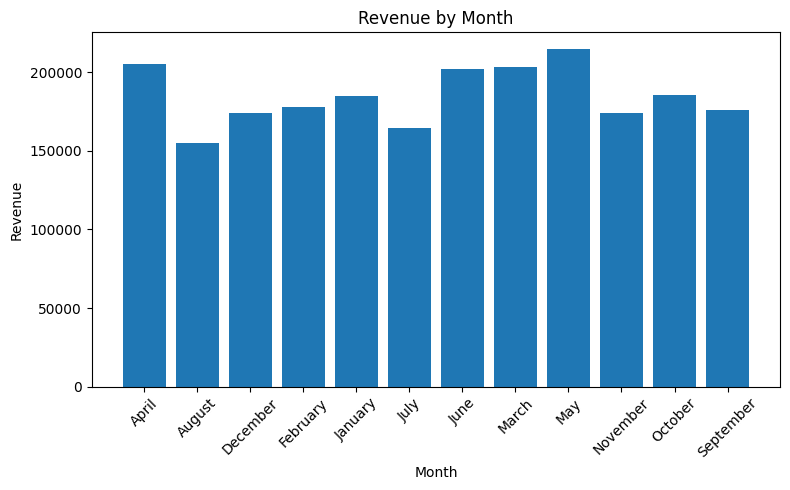

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    monthly_revenue['ride_month'],
    monthly_revenue['fare _amount']
)

plt.title('Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

This chart shows the revenue generated across different months. It helps identify the highest-performing and lowest-performing months.

In [3]:
hourly_trips = df.groupby ('ride_hour') ['ride_id'].count () .reset_index(name='total_trips')
hourly_trips

,ride_hour,total_trips
0,0,7653
1,1,5751
2,2,4300
3,3,3160
4,4,2290
5,5,1897
6,6,4015
7,7,7036
8,8,8847
9,9,9103


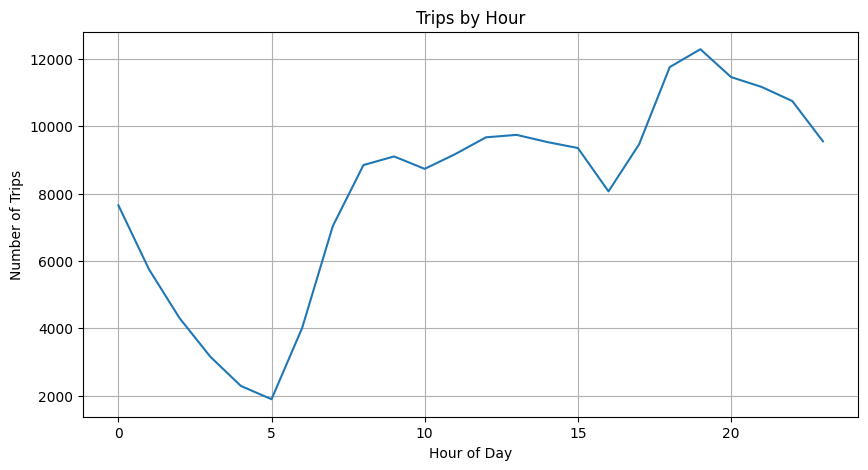

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    hourly_trips['ride_hour'],
    hourly_trips['total_trips']
)

plt.title('Trips by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.grid('True')

plt.show()

### Insight

This chart shows trip demand throughout the day and helps identify peak booking hours.

In [11]:
hourly_trips.sort_values (by='total_trips', ascending=False) .head(5)

,ride_hour,total_trips
19,19,12285
18,18,11755
20,20,11459
21,21,11165
22,22,10747


In [22]:
hourly_trips = df.groupby ('ride_hour') ['fare _amount'].sum () .reset_index(name='revenue')
hourly_trips

,ride_hour,revenue
0,0,88953.83
1,1,66998.21
2,2,48995.44
3,3,37160.99
4,4,32469.35
5,5,30681.31
6,6,48272.96
7,7,78494.03
8,8,96739.37
9,9,100226.16


In [23]:
hourly_trips.sort_values(by='revenue',ascending=False).head(5)

,ride_hour,revenue
19,19,130036.50
18,18,129009.59
20,20,123609.03
21,21,122570.66
22,22,121936.04


In [27]:
day_trips = df.groupby ('Day_name') ['fare _amount'].sum () .reset_index(name='revenue')
day_trips

,Day_name,revenue
0,Friday,344598.17
1,Monday,280464.43
2,Saturday,325696.45
3,Sunday,303482.92
4,Thursday,337672.79
5,Tuesday,304798.76
6,Wednesday,321635.13


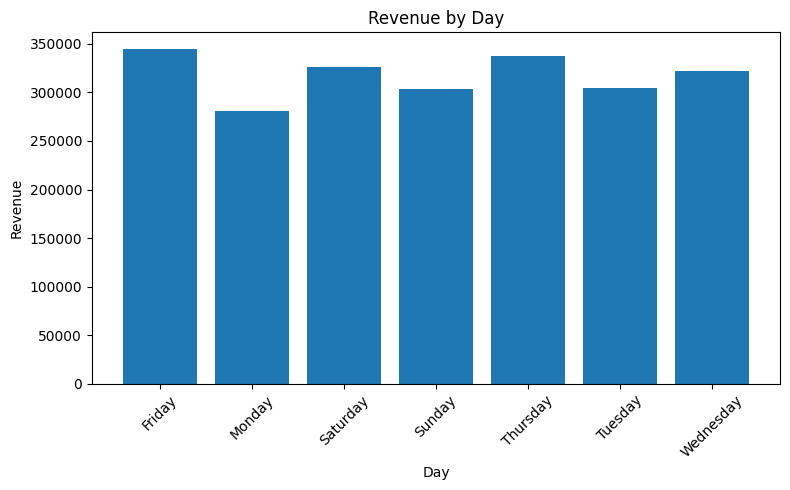

In [32]:
plt.figure(figsize=(8,5))

plt.bar(
    day_trips['Day_name'],
    day_trips['revenue']
)

plt.title('Revenue by Day')
plt.xlabel('Day')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Weekday Performance Analysis

### Revenue by Day of Week

This chart compares revenue across weekdays to identify the strongest-performing days and understand weekly demand trends.

In [28]:
passenger_analysis = df.groupby ('passenger_count') ['ride_id'].count () .reset_index(name='total_trips')
passenger_analysis

,passenger_count,total_trips
0,1,135140
1,2,28828
2,3,8693
3,4,4177
4,5,13707
5,6,4203


In [30]:
passenger_revenue = df.groupby ('passenger_count') ['fare _amount'].sum () .reset_index(name='revenue')
passenger_revenue

,passenger_count,revenue
0,1,1524752.79
1,2,340143.06
2,3,99613.10
3,4,48673.88
4,5,153899.34
5,6,51266.48


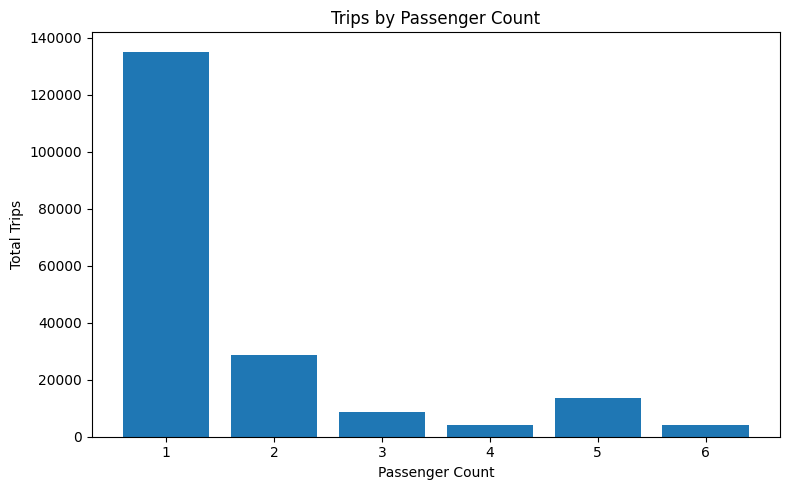

In [33]:
plt.figure(figsize=(8,5))

plt.bar(
    passenger_analysis['passenger_count'],
    passenger_analysis['total_trips']
)

plt.title('Trips by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Total Trips')

plt.tight_layout()
plt.show()

## Passenger Analysis

### Trip Distribution by Passenger Count

This visualization shows how trips are distributed among different passenger groups. It helps determine whether solo travelers dominate ride demand.

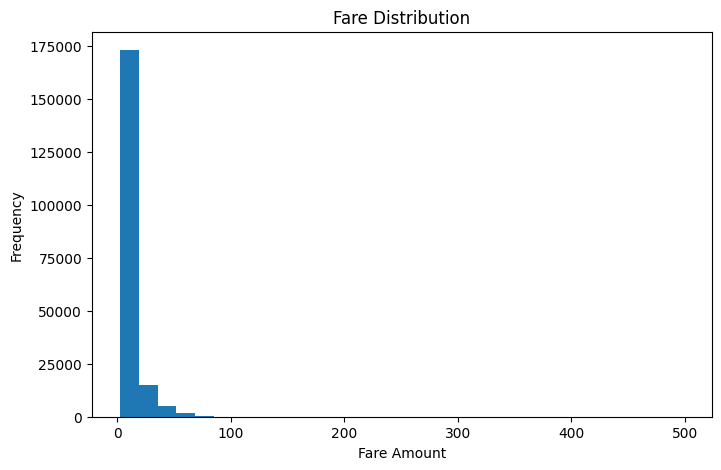

In [34]:
plt.figure(figsize=(8,5))

plt.hist(
    df['fare _amount'],
    bins=30
)

plt.title('Fare Distribution')
plt.xlabel('Fare Amount')
plt.ylabel('Frequency')

plt.show()

## Fare Analysis

### Fare Distribution

The histogram illustrates how fare amounts are distributed across all trips. It helps identify common fare ranges and understand the overall pricing pattern.

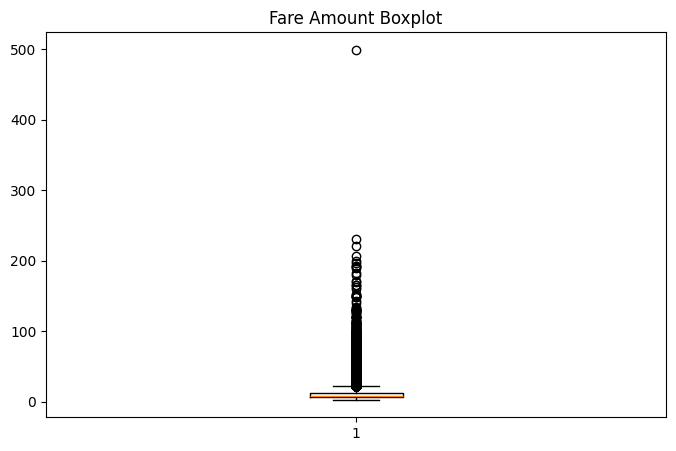

In [35]:
plt.figure(figsize=(8,5))

plt.boxplot(
    df['fare _amount']
)

plt.title('Fare Amount Boxplot')

plt.show()

## Outlier Analysis

### Fare Amount Boxplot

This boxplot is used to detect unusually high or low fare values. Identifying outliers helps assess data quality and uncover exceptional ride patterns.

# Key Insights

1. The highest revenue was generated during the top-performing month.
2. Peak ride demand occurred during specific hours of the day.
3. Certain weekdays generated significantly higher revenue than others.
4. Single-passenger trips represented the largest share of total rides.
5. Fare distribution was concentrated within a specific range, with a few high-value outliers.
6. A small number of trips contributed exceptionally high fare amounts.
7. Revenue patterns indicate opportunities for demand-based operational planning.